In [5]:
import os
import matplotlib.pyplot as plt
from notebooks.visualization.activations_funcs import get_activation_dictionnary
from notebooks.visualization.random_networks_plots.plot_config import apply_plot_style
from notebooks.visualization.activations_funcs import get_all_connections
from paths import PROJECT_ROOT
plots_dir = os.path.join(PROJECT_ROOT, "plots")
from notebooks.visualization.random_networks_plots.plot_config import RANDOMIZATION_NAMES
NUM_PASSES = 3

apply_plot_style()

# Create plots directory if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)


from utils.helpers import load_neuron_coordinates

from joblib import Memory


cache_dir = os.path.join(PROJECT_ROOT, "notebooks", "visualization", "data", ".joblib_cache")
memory = Memory(location=cache_dir, verbose=0)


@memory.cache
def connections_cached():
    """Disk-cached version of get_all_connections()."""
    return get_all_connections()


@memory.cache
def activations_cached(num_passes: int = 4):
    """Disk-cached wrapper around get_activation_dictionnary()."""
    conn_dict = connections_cached()
    return get_activation_dictionnary(conn_dict, num_passes)

neuron_position_data = load_neuron_coordinates()

# Heavy cached computations
connections_dict = connections_cached()
activations_dict = activations_cached(NUM_PASSES)

# remove random pruned from both
connections_dict.pop(RANDOMIZATION_NAMES["random_pruned"])
activations_dict.pop(RANDOMIZATION_NAMES["random_pruned"])

,root_id,input,activation_1,activation_2,activation_3
0,720575940596125868,0.0,0.0,0.000000,54.847743
1,720575940597856265,0.0,0.0,4.662577,-229.172382
2,720575940597944841,0.0,0.0,-2.992619,-231.093259
3,720575940598267657,0.0,0.0,10.665208,-748.561821
4,720575940599333574,0.0,0.0,-1.005776,-90.591939
...,...,...,...,...,...
138634,720575940622742286,0.0,0.0,0.000000,0.000000
138635,720575940629719811,0.0,0.0,0.000000,1.442132
138636,720575940639046372,0.0,0.0,0.000000,-0.822484
138637,720575940633284895,0.0,0.0,0.000000,-0.254070


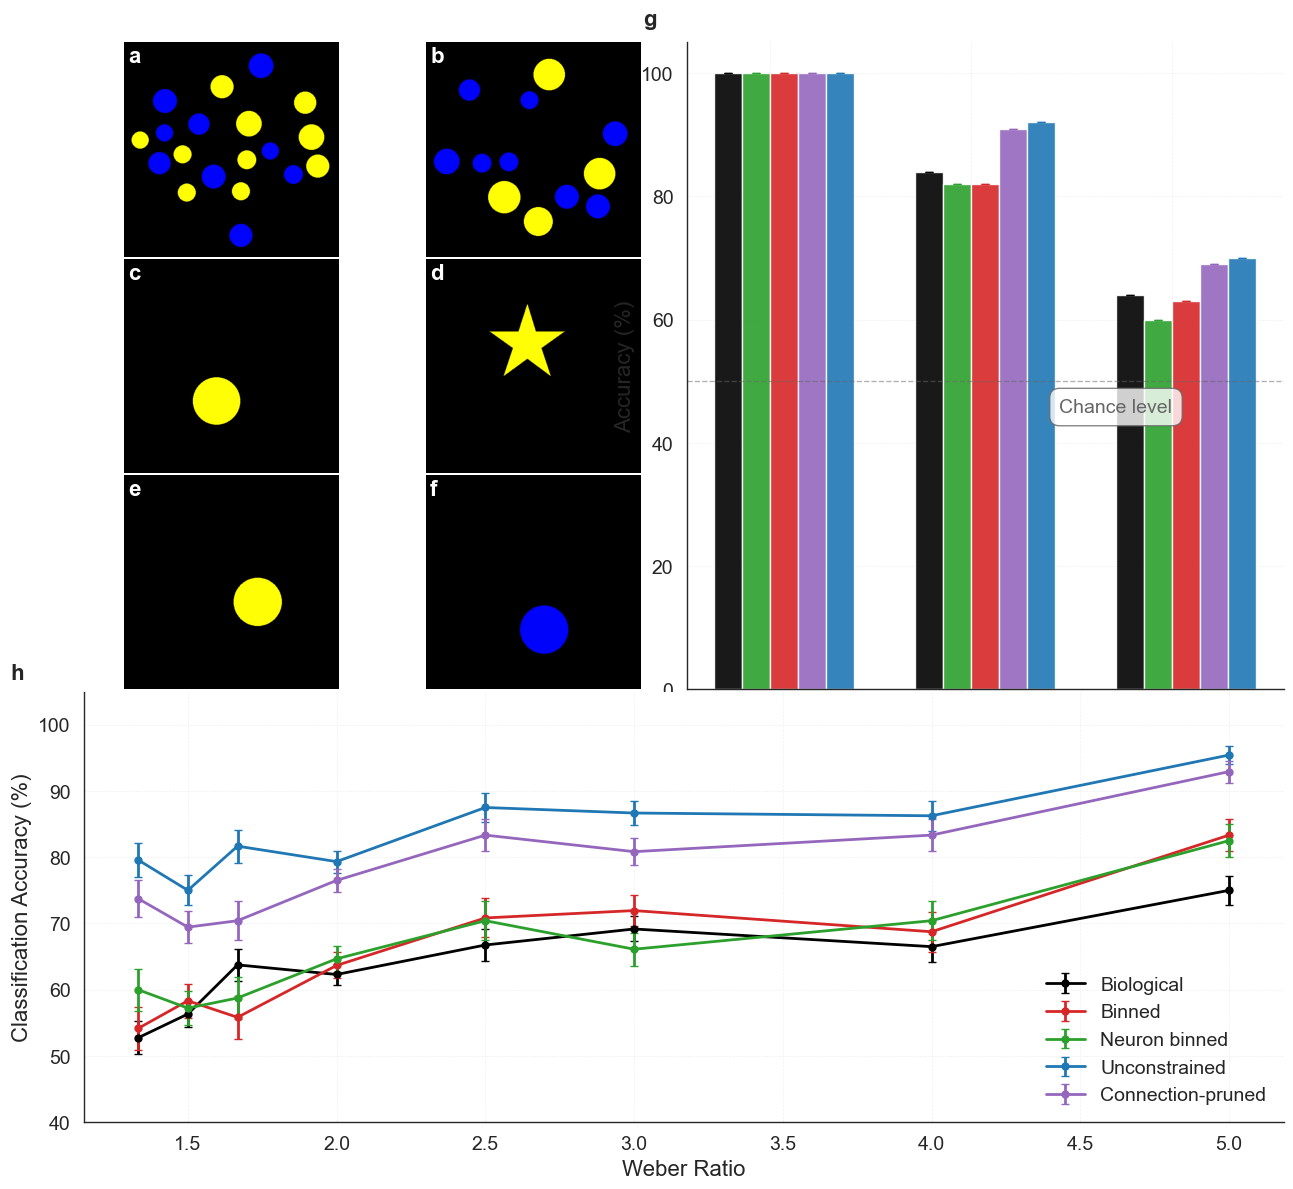

In [18]:
import importlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.image import imread
import pandas as pd

plt.close('all')

ORDER = ["Biological", "Binned", "Neuron binned", "Unconstrained", "Connection-pruned"]
NAME_ALIAS = {
    "biological": "biological",
    "binned": "random_binned",
    "random_binned": "random_binned",
    "neuron_binned": "neuron_binned",
    "unconstrained": "unconstrained",
    "connection_pruned": "connection_pruned",
}

from notebooks.visualization.random_networks_plots import models_accuracy
from notebooks.visualization.random_networks_plots import plot_config
from connectome.visualization import plots
importlib.reload(models_accuracy)
importlib.reload(plot_config)
importlib.reload(plots)

from notebooks.visualization.random_networks_plots.models_accuracy import task_accuracy_comparison
from connectome.visualization.plots import plot_weber_by_randomization

# Load task images
task_images_dir = os.path.join(PROJECT_ROOT, "notebooks", "visualization", "task_images")
images = [imread(os.path.join(task_images_dir, f"t{i}.png")) for i in range(1, 7)]

# Create figure with gridspec: 5 rows x 4 columns
# Top: images (3x2) + task_accuracy (3x2)
# Bottom: weber (2x4)
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(5, 4, figure=fig, hspace=0.01, wspace=0.02, left=0.0, right=1.0, top=0.98, bottom=0.08)

# Top section: task images (3 rows x 2 cols) - all the way to the left
ax_imgs = []
for row in range(3):
    for col in range(2):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(images[row * 2 + col])
        ax.axis('off')
        ax.set_aspect('equal')
        ax_imgs.append(ax)

# task_accuracy_comparison (3 rows x 2 cols)
ax_task = fig.add_subplot(gs[0:3, 2:4])
task_accuracy_comparison(ax=ax_task, show_legend=False)

# Bottom section: weber (2 rows x 4 cols)
ax_weber = fig.add_subplot(gs[3:5, 0:4])
plot_weber_by_randomization(
    folder=os.path.join(PROJECT_ROOT, "supplementary_data"),
    min_weber=1.2,
    ax=ax_weber,
    show_legend=True
)

# Panel labels (a-f for images inside plots in white, g and h outside)
for i, ax in enumerate(ax_imgs):
    ax.text(0.02, 0.98, chr(ord('a') + i), transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='left', color='white')

ax_task.text(-0.05, 1.02, 'g', transform=ax_task.transAxes, 
             fontsize=16, fontweight='bold', va='bottom', ha='right')
ax_weber.text(-0.05, 1.02, 'h', transform=ax_weber.transAxes, 
              fontsize=16, fontweight='bold', va='bottom', ha='right')

plt.show()

fig.savefig(os.path.join(plots_dir, "figure_3.pdf"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(plots_dir, "figure_3.png"), dpi=300, bbox_inches='tight')